In [1]:
from pykrx import stock
import time
import matplotlib.pyplot as plt

['095570', '006840', '027410', '282330', '138930']
['060310', '054620', '265520', '211270', '032790']


https://appia.tistory.com/426?category=903900
https://github.com/sharebook-kr/pykrx

In [61]:
market_cap = stock.get_market_cap("20220304")
# 2022 3월 4일 기준으로 시가총액 상위 10개의 번호를 가져옴
market_cap_sort = market_cap['시가총액'].sort_values(ascending=False).head(10)
num2name = {}
tickers = stock.get_market_ticker_list("20220304", market="KOSPI")
for ticker in stock.get_market_ticker_list():
        num2name[ticker] = stock.get_market_ticker_name(ticker)

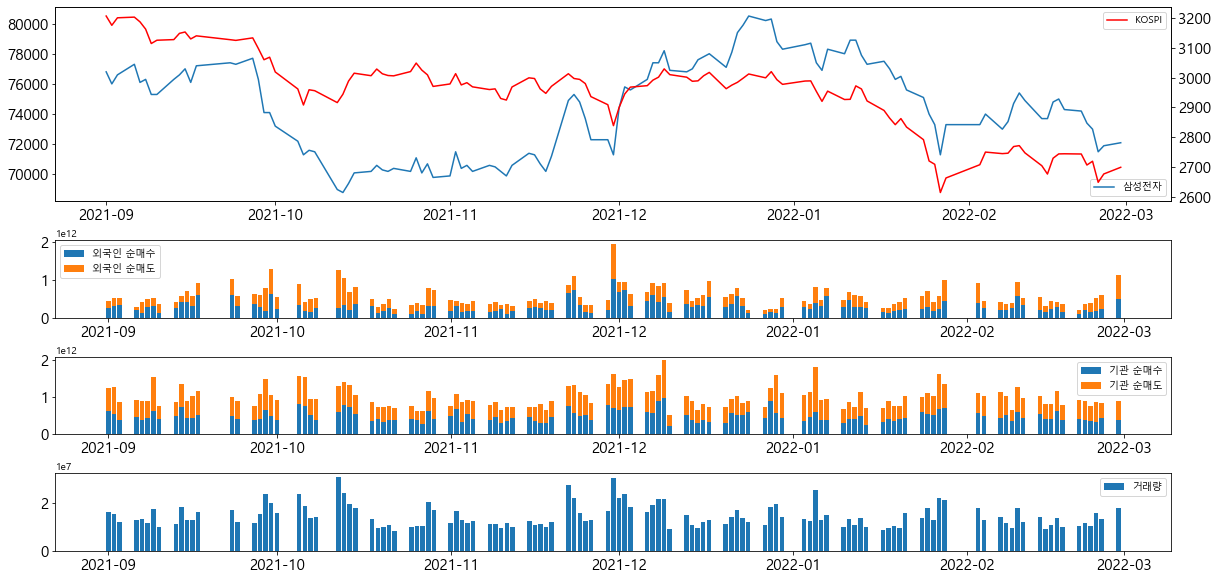

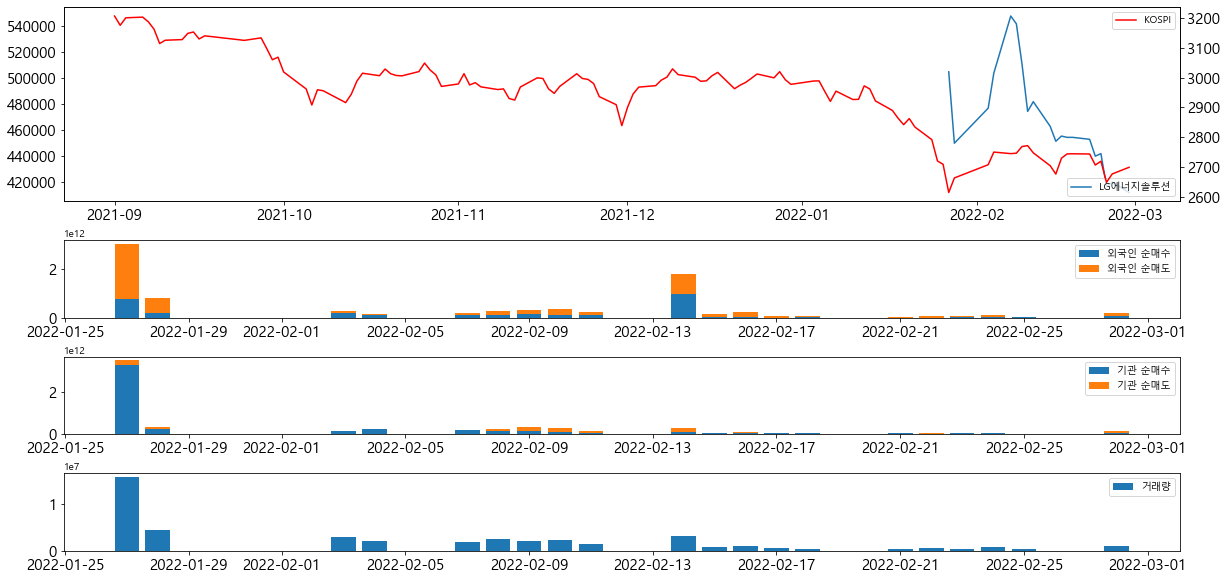

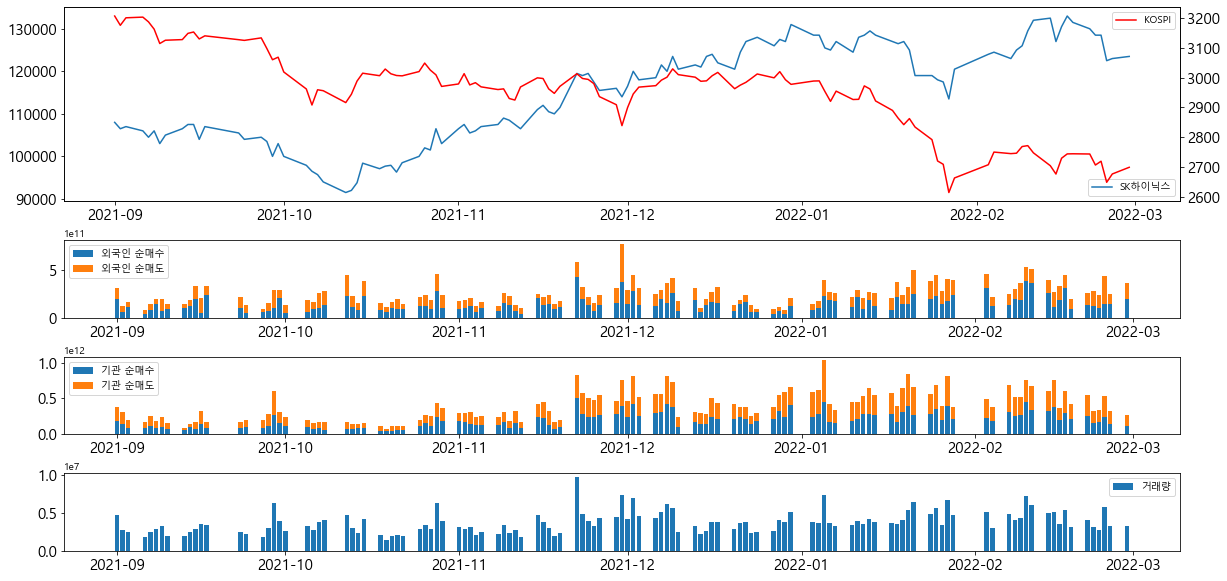

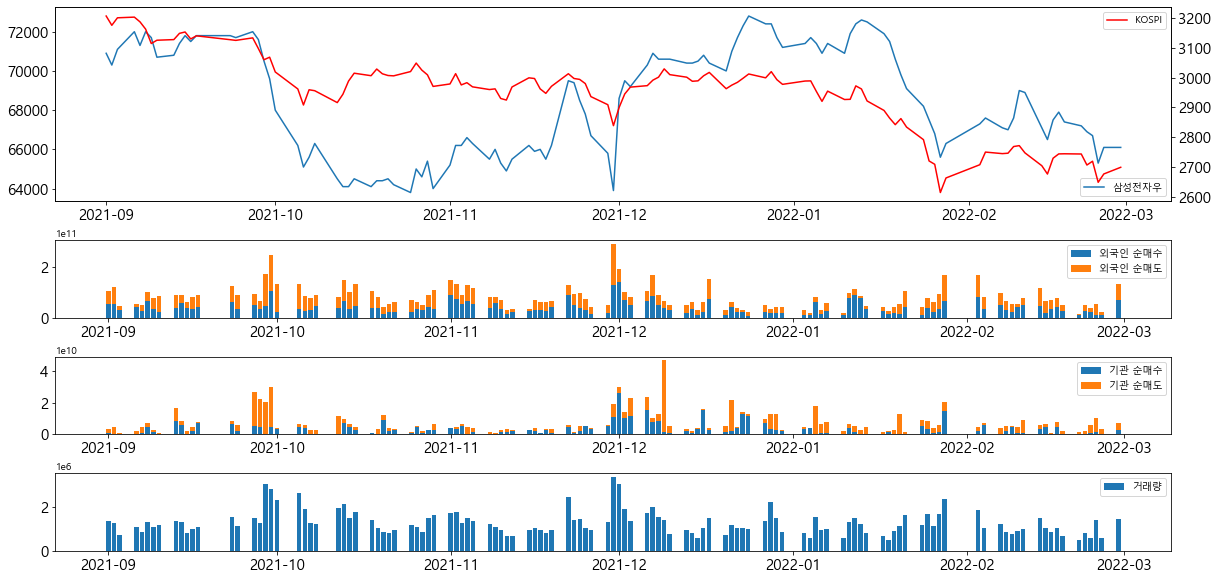

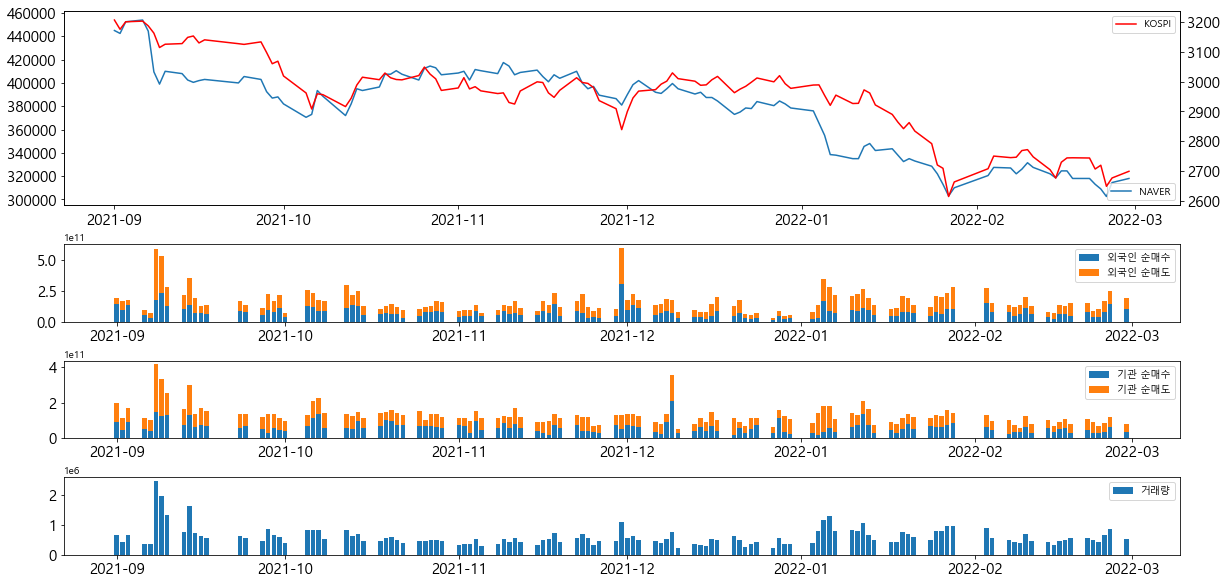

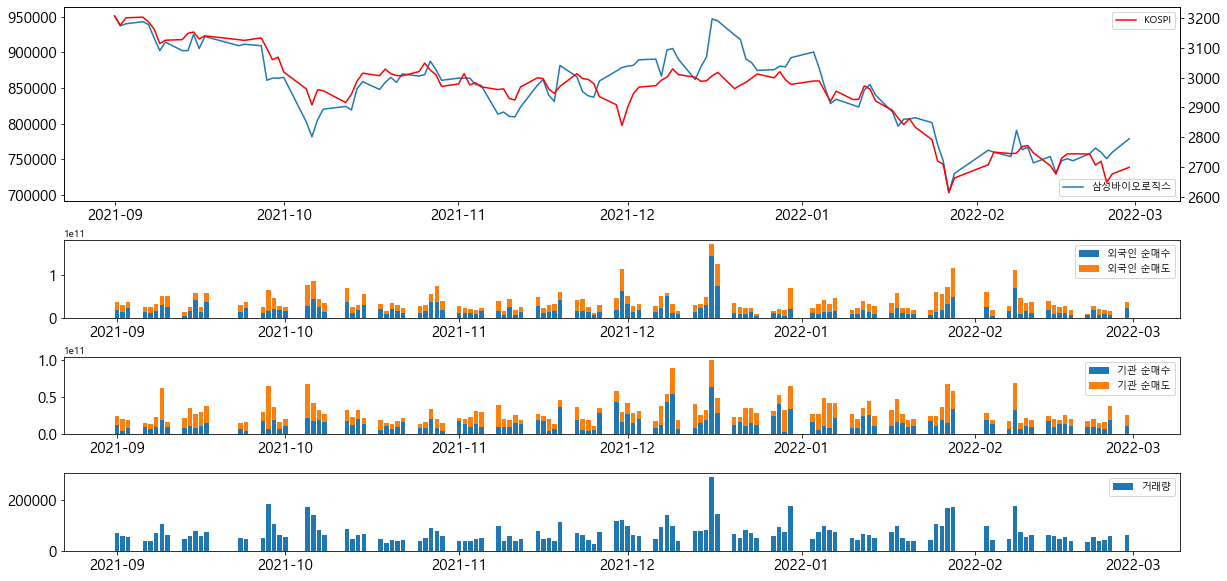

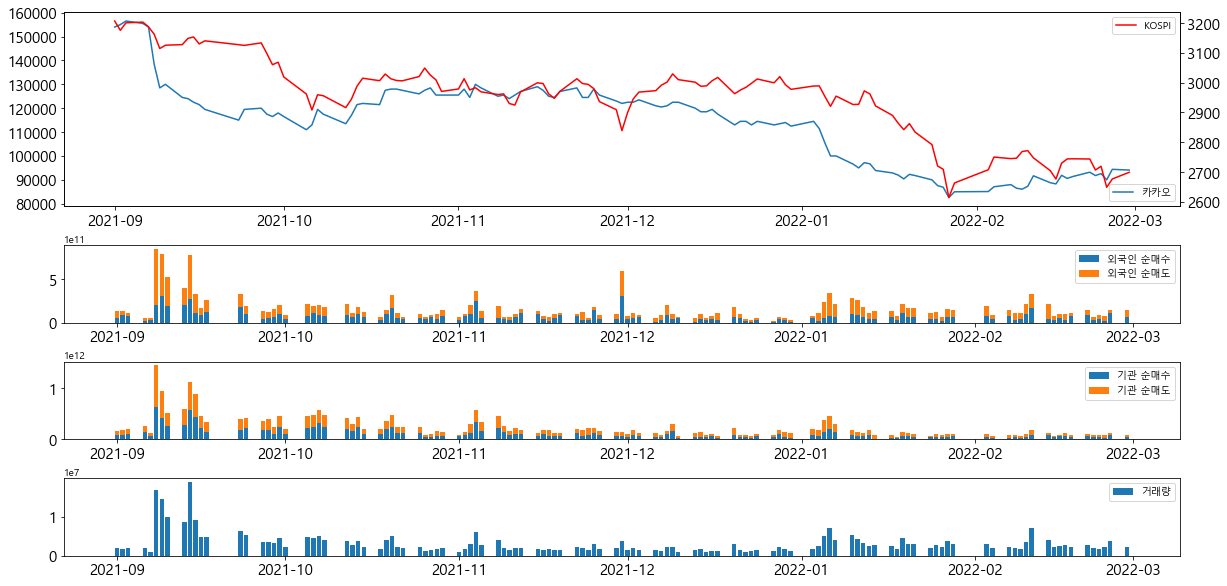

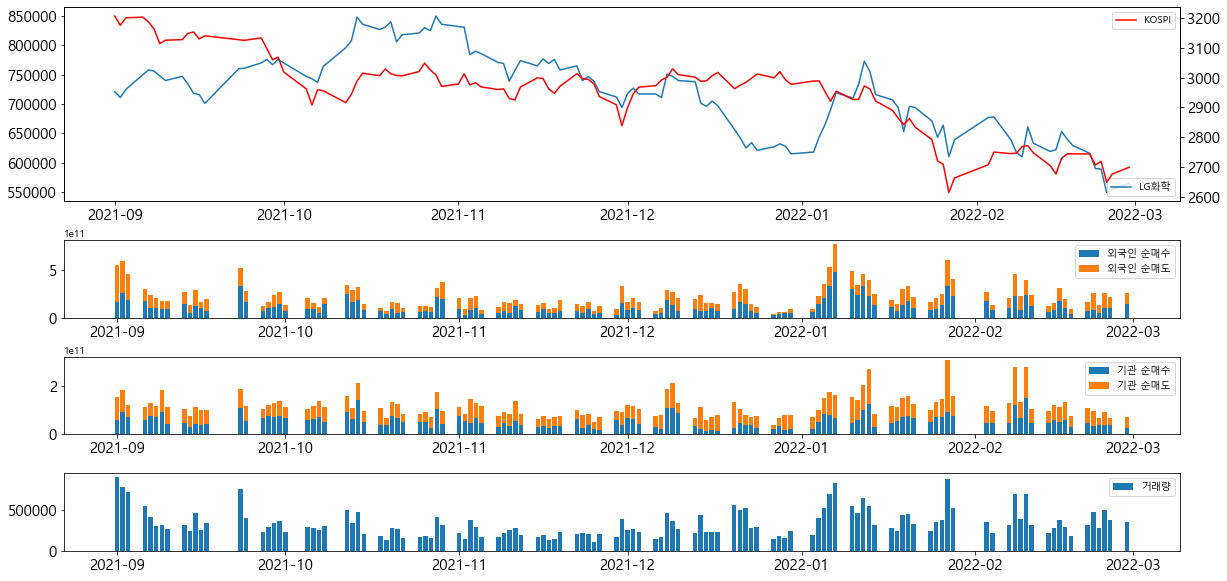

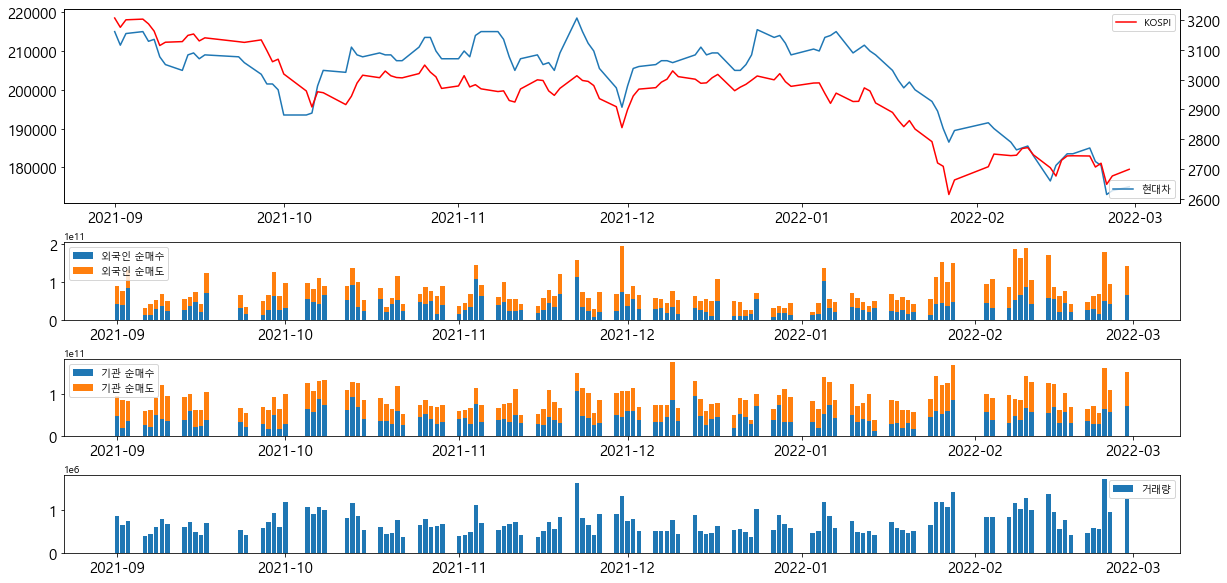

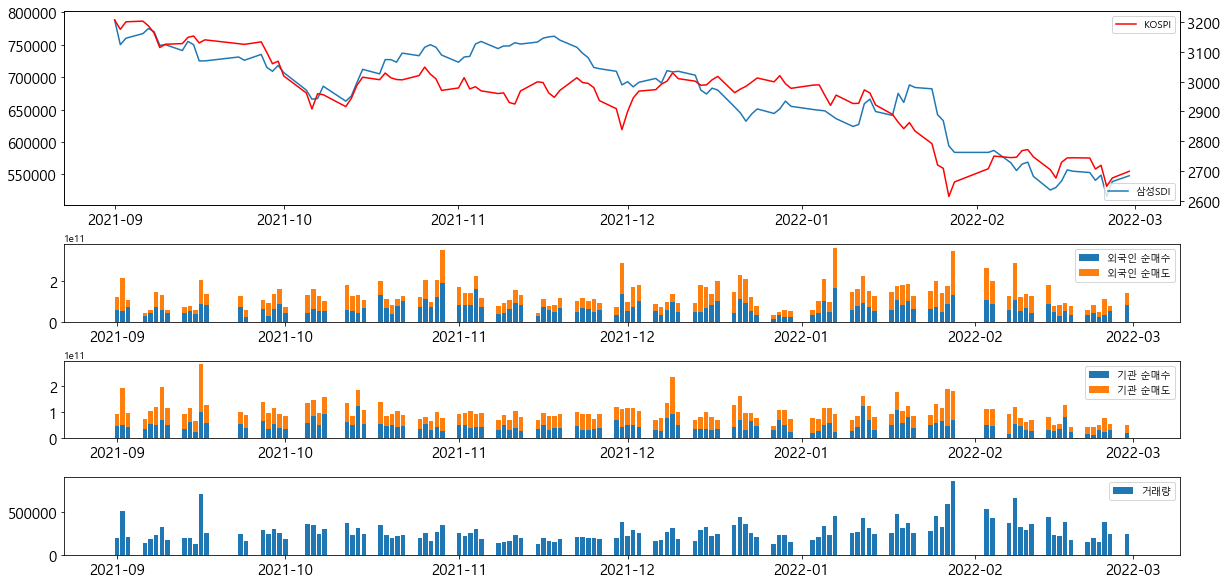

In [62]:
start_date = '20210901'
end_date = '20220301'
df = stock.get_index_ohlcv(start_date, end_date, "1001")

fontsize_=15
for num in market_cap_sort.index:
    
    df_tmp = stock.get_market_ohlcv_by_date(start_date, end_date, num)
    buy = stock.get_market_trading_value_by_date(start_date, end_date, num , on='매수')
    sell = stock.get_market_trading_value_by_date(start_date, end_date, num , on='매도')
    
    plt.figure(figsize=(20,10))
    plt.subplots_adjust(hspace=0.5, wspace=0.4)

    gridshape=(5,1)
    loc=(0,0)
    plt.subplot2grid(gridshape, loc, rowspan=2)
    plt.plot(df_tmp['종가'], label=num2name[num])
    plt.legend(loc='lower right')
    plt.xticks(fontsize=fontsize_)
    plt.yticks(fontsize=fontsize_)
    plt.twinx()
    plt.plot(df['종가'], color='r', label='KOSPI')
    plt.xticks(fontsize=fontsize_)
    plt.yticks(fontsize=fontsize_)
    plt.legend()

    loc=(2,0)
    plt.subplot2grid(gridshape, loc)
    plt.bar(buy['외국인합계'].index, buy['외국인합계'], label='외국인 순매수')
    plt.bar(sell['외국인합계'].index, sell['외국인합계'], label='외국인 순매도', bottom=buy['외국인합계'])
    plt.xticks(fontsize=fontsize_)
    plt.yticks(fontsize=fontsize_)
    plt.legend()

    loc=(3,0)
    plt.subplot2grid(gridshape, loc)
    plt.bar(buy['기관합계'].index, buy['기관합계'], label='기관 순매수')
    plt.bar(sell['기관합계'].index, sell['기관합계'], label='기관 순매도', bottom=buy['기관합계'])
    plt.xticks(fontsize=fontsize_)
    plt.yticks(fontsize=fontsize_)
    plt.legend()

    loc=(4,0)
    plt.subplot2grid(gridshape, loc, colspan=3)
    plt.bar(df_tmp['거래량'].index, df_tmp['거래량'], label='거래량')
    plt.xticks(fontsize=fontsize_)
    plt.yticks(fontsize=fontsize_)
    plt.legend()
    plt.show()
    